In [ ]:
 %%script echo skipping
 """
urban_mining_refactored.ipynb
Detect urban settlement and mining in a single image
Calculate centroids of these categories and distance between them. Show on overlay image.

Problem: simiple arithmetic operations (NDBI) lump built environments and can not differentiate between urban settlement types (dense / sprawl / slum)
Solution: Supply sample areas, including negatives, to tune a simple classifier.
RTS with ChatGPT, November 2025

The script ingests a 10-band Sentinel-2 GeoTIFF and user-drawn scribbles for mining, urban, and background.
It builds spectral-texture features, trains simple centroid-based binary classifiers (mining vs non-mining, urban vs non-urban)
using positive and negative samples. Morphology, NDVI/NDBI gates and distance constraints reduce false positives,
producing final mining/urban masks and centroids.
"""

skipping


In [1]:
# variables specific to your CoLabsetup ----------------------------------------
from google.colab import drive
import sys

drive.mount('/content/drive')
root = '/content/drive/MyDrive/Colab/research/'
sys.path.append(root +"code/")
datapath = root + "data/"
ext_datapath = '/content/drive/MyDrive/Projects/Nudge-X/sites/'
sys.path.append(root +'code/')

Mounted at /content/drive


In [2]:
%%capture
!pip install rasterio
import rasterio

In [3]:
import os, math
import numpy as np
import rasterio
import imageio.v2 as imageio
import matplotlib
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

#helper functions
#from urban_mining_helper import *

In [4]:
#refactored helper functions
from config import make_default_config
from features import load_multiband_and_samples, build_feature_stack_10band, write_mask_tif
from samples import extract_masks_from_colors
from classifiers import train_scene_classifiers, classify_and_postprocess
from overlay import compute_centroid_distance, make_overlay

In [5]:
def main():

    # Set inputs
    multiband_path = ext_datapath + "RixCreekOpenCutMine_urban_mining_2024-12-29.tif"
    version = "_rgb_outlines.png"
    samples_path  = multiband_path.split('.tif')[0] + version
    config = make_default_config(multiband_path, samples_path)

    # 1) Load data
    bands, samples_rgb, profile = load_multiband_and_samples(config)

    # 2) Features
    feat_stack, aux = build_feature_stack_10band(bands)
    H, W, D = feat_stack.shape

    # 3) Sample masks
    mining_sample, urban_sample, neg_sample = extract_masks_from_colors(
        samples_rgb, [config.mining_colors, config.urban_colors, config.negative_colors],
        config.color_tol,)

    print("Sample pixels – mining:",int(mining_sample.sum()),
          "urban:", int(urban_sample.sum()),
          "negative:", int(neg_sample.sum()))

    if mining_sample.sum() < 50 or urban_sample.sum() < 50 or neg_sample.sum() < 50:
        raise SystemExit("Need at least ~50 pixels for each of mining, urban, and negative samples.")

    # 4) Train classifiers
    mining_clf, urban_clf = train_scene_classifiers(feat_stack, mining_sample, urban_sample, neg_sample, config)

    # 5) Classify full image + postprocess
    mine_mask, urban_mask = classify_and_postprocess(
        feat_stack, aux, mining_clf, urban_clf,
        mining_sample, urban_sample, neg_sample,
        profile, config,)

    print("Final mining pixels:", int(mine_mask.sum()))
    print("Final urban pixels :", int(urban_mask.sum()))
    print("Extra mining pixels outside samples:", int((mine_mask & ~mining_sample).sum()))
    print("Extra urban pixels outside samples :", int((urban_mask & ~urban_sample).sum()))

    # 6) Centroids & distances
    mine_c_px, urban_c_px, mine_c_map, urban_c_map, dist = compute_centroid_distance(
        mine_mask, urban_mask, profile)

    # 7) Save masks
    #write_mask_tif(f"{config.out_prefix}_mining_mask.tif", mine_mask, profile)
    #write_mask_tif(f"{config.out_prefix}_urban_mask.tif",  urban_mask, profile)
    # PNGs
    #import imageio.v2 as imageio
    #imageio.imwrite(f"{config.out_prefix}_mining_mask.png", (mine_mask.astype("uint8") * 255))
    #imageio.imwrite(f"{config.out_prefix}_urban_mask.png",  (urban_mask.astype("uint8") * 255))

    # 8) Overlay with centroid line
    make_overlay(
        aux["nir01"], mine_mask, urban_mask,
        mine_centroid_px=mine_c_px,
        urban_centroid_px=urban_c_px,
        out_path=f"{config.out_prefix}_overlay.png",)

    print("Saved:")
    #print("  ", f"{config.out_prefix}_mining_mask.(tif|png)")
    #print("  ", f"{config.out_prefix}_urban_mask.(tif|png)")
    print("  ", f"{config.out_prefix}_overlay.png")

Sample pixels – mining: 88646 urban: 95349 negative: 264506
Training mining classifier...
  pos samples: 88646 neg samples: 50000
  best F1=0.858 at thr=-2.552
Training urban classifier...
  pos samples: 95349 neg samples: 50000
  best F1=0.852 at thr=-6.775
Final mining pixels: 78594
Final urban pixels : 207221
Extra mining pixels outside samples: 10869
Extra urban pixels outside samples : 129919
Mining centroid (map x,y): 323482.29, 6401772.70
Urban  centroid (map x,y): 326679.55, 6398137.20
Distance between mining and urban centroids: 4841.42 meters


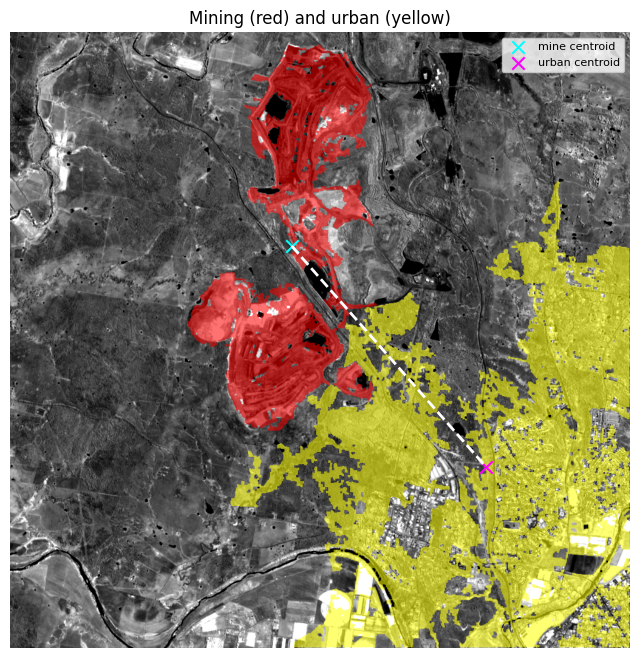

Saved:
   /content/drive/MyDrive/Projects/Nudge-X/sites/RixCreekOpenCutMine_urban_mining_2024-12-29_overlay.png


In [6]:
if __name__ == "__main__":
    main()